# 18 — Model Comparison & Risk Stratification

Compares all four survival models on the shared 5-fold CV splits:
- mRNA-only LASSO-Cox (script 11)
- Multi-omics LASSO-Cox (script 12)
- mRNA-only NN Cox (script 16, best params from tuning script 14)
- Multi-omics NN Cox (script 17, best params from tuning script 15)

Evaluation: C-index per fold, Wilcoxon signed-rank tests, and KM risk group curves.

**Note on KM curves:** risk score files must be saved by scripts 11, 12, 16 and 17 first (updated scripts)

### Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from pathlib import Path

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    HAS_LIFELINES = True
except ImportError:
    HAS_LIFELINES = False
    print("lifelines not installed. pip install lifelines")

Path("../results/figures").mkdir(parents=True, exist_ok=True)
Path("../results/tables").mkdir(parents=True, exist_ok=True)

COLORS = {
    "mRNA-only LASSO":   "#7F77DD",
    "Multi-omics LASSO": "#1D9E75",
    "mRNA-only NN":      "#D85A30",
    "Multi-omics NN":    "#BA7517",
}
ORDER = ["mRNA-only LASSO", "Multi-omics LASSO", "mRNA-only NN", "Multi-omics NN"]

In [2]:

# load all four model result files
lasso_mrna  = pd.read_csv("../results/tables/lasso_cox_cv_results.csv")
lasso_multi = pd.read_csv("../results/tables/lasso_cox_multiomics_cv_results.csv")
nn_mrna     = pd.read_csv("../results/tables/nn_mRNA_only_best_model_folds.csv")
nn_multi    = pd.read_csv("../results/tables/nn_integrated_best_model_folds.csv")

surv = pd.read_csv("../data/processed/survival_luminal_clean.csv").set_index("patient")

lasso_mrna["model"]  = "mRNA-only LASSO"
lasso_multi["model"] = "Multi-omics LASSO"
nn_mrna["model"]     = "mRNA-only NN"
nn_multi["model"]    = "Multi-omics NN"

combined = pd.concat([lasso_mrna, lasso_multi, nn_mrna, nn_multi], ignore_index=True)
print("All four models loaded.")
print(combined.groupby("model")["test_c_index"].agg(["mean","std"]).round(3))

All four models loaded.
                    mean    std
model                          
Multi-omics LASSO  0.585  0.105
Multi-omics NN     0.640  0.195
mRNA-only LASSO    0.576  0.078
mRNA-only NN       0.621  0.056


## 1) Model Performance Comparison (C-index)


### 1.1) Overall ranking


In [3]:

# performance summary table
summary = (
    combined.groupby("model")["test_c_index"]
    .agg(mean="mean", std="std", min="min", max="max")
    .round(3)
    .reset_index()
)
summary["model"] = pd.Categorical(summary["model"], categories=ORDER, ordered=True)
summary = summary.sort_values("model").reset_index(drop=True)
summary.to_csv("../results/tables/all_models_performance_summary.csv", index=False)
print(summary.to_string(index=False))

            model  mean   std   min   max
  mRNA-only LASSO 0.576 0.078 0.495 0.684
Multi-omics LASSO 0.585 0.105 0.432 0.701
     mRNA-only NN 0.621 0.056 0.563 0.710
   Multi-omics NN 0.640 0.195 0.311 0.831


C:\Users\laral\AppData\Local\Temp\ipykernel_18960\2836992593.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")


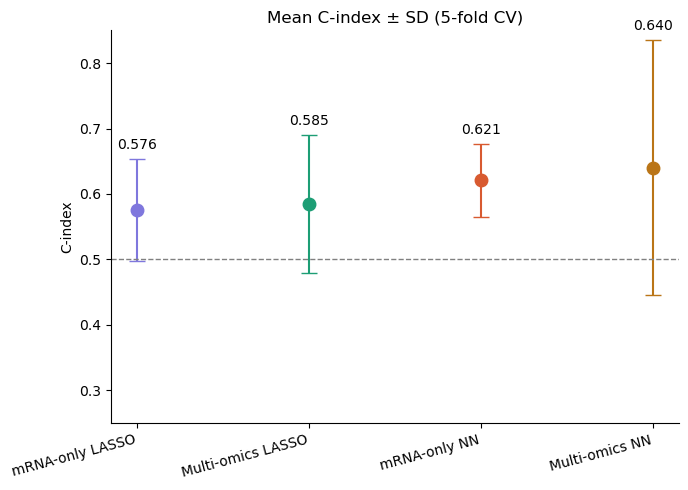

In [4]:

# visualization of mean C-index +/- SD
fig, ax = plt.subplots(figsize=(7, 5))
for _, row in summary.iterrows():
    ax.errorbar(row["model"], row["mean"], yerr=row["std"],
                fmt="o", capsize=6, markersize=9, color=COLORS[row["model"]])
    ax.text(row["model"], row["mean"] + row["std"] + 0.015,
            f'{row["mean"]:.3f}', ha="center", fontsize=10)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title("Mean C-index ± SD (5-fold CV)")
ax.set_ylabel("C-index")
ax.set_ylim(0.25, 0.85)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/cindex_all_models_mean_sd.png", dpi=300)
plt.show()

- Multi-omics NN best mean C-index (0.640), but widest error bar (SD=0.195)
- mRNA-only LASSO lowest mean C-index (0.576)
- mRNA-only NN best balance of performance and stability (mean=0.621, SD=0.056)
- Adding methylation improves both model families; NNs outperform LASSO in both settings


### 1.2) Stability across folds


C:\Users\laral\AppData\Local\Temp\ipykernel_18960\1634258787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x="model", y="test_c_index", order=model_order,
C:\Users\laral\AppData\Local\Temp\ipykernel_18960\1634258787.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")


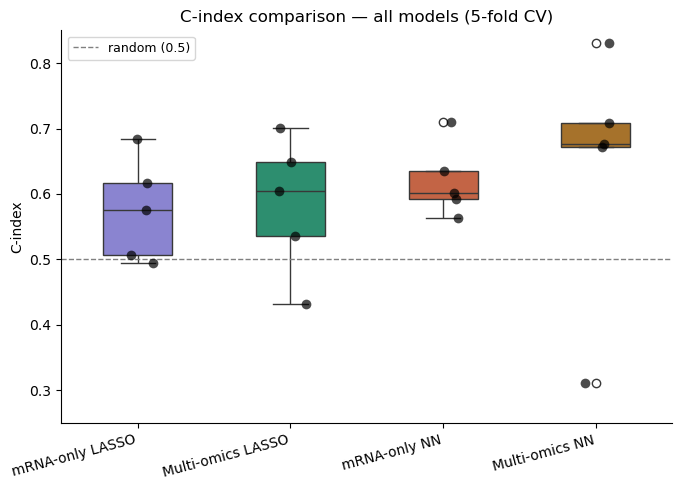

In [5]:

# C-index boxplot
model_order = [m for m in ORDER if m in combined["model"].unique()]
palette = {m: COLORS[m] for m in model_order}

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=combined, x="model", y="test_c_index", order=model_order,
            palette=palette, width=0.45, ax=ax)
sns.stripplot(data=combined, x="model", y="test_c_index", order=model_order,
              color="black", alpha=0.7, size=7, ax=ax)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random (0.5)")
ax.set_title("C-index comparison — all models (5-fold CV)")
ax.set_xlabel("")
ax.set_ylabel("C-index")
ax.set_ylim(0.25, 0.85)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/cindex_all_models_boxplot.png", dpi=300)
plt.show()

- Multi-omics NN highest median but two extreme outlier folds (0.311 and 0.831)
- mRNA-only NN most consistent — all five folds between 0.563 and 0.710


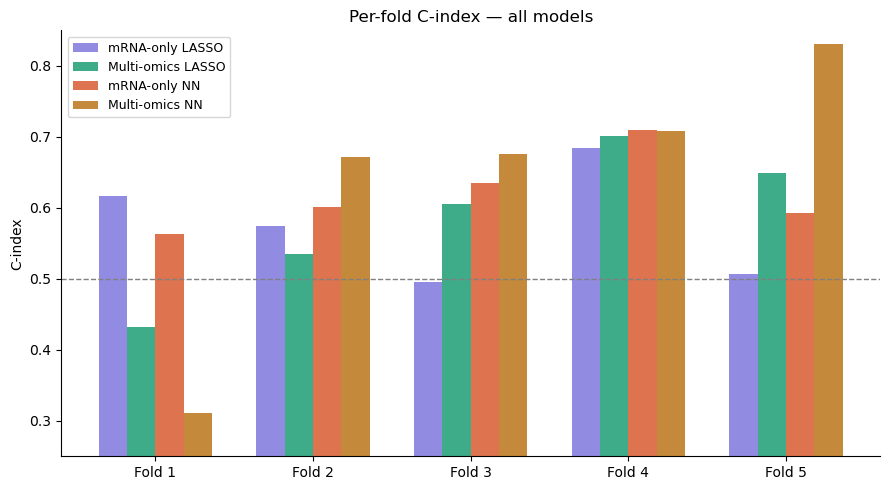

In [6]:

# per-fold C-index bar chart
fig, ax = plt.subplots(figsize=(9, 5))
n_models = len(model_order)
width = 0.18
x = np.arange(1, 6)

for i, model in enumerate(model_order):
    subset = combined[combined["model"] == model].sort_values("fold")
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, subset["test_c_index"], width,
           label=model, color=COLORS[model], alpha=0.85)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {f}" for f in range(1, 6)])
ax.set_ylabel("C-index")
ax.set_title("Per-fold C-index — all models")
ax.set_ylim(0.25, 0.85)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/cindex_per_fold_all_models.png", dpi=300)
plt.show()

- All models agree: fold 4 easiest, fold 3 hardest for LASSO, fold 1 hardest for Multi-omics NN
- Variance is data-driven (fold composition) rather than model instability


#### LASSO feature selection stability


C:\Users\laral\AppData\Local\Temp\ipykernel_18960\773508648.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lasso_only, x="model", y="n_features_selected",


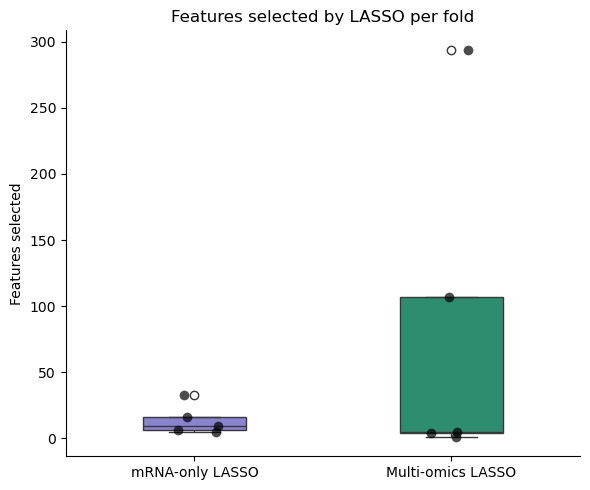

In [7]:

# feature selection — LASSO models only
lasso_only = combined[combined["model"].isin(["mRNA-only LASSO", "Multi-omics LASSO"])]

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=lasso_only, x="model", y="n_features_selected",
            palette={"mRNA-only LASSO": COLORS["mRNA-only LASSO"],
                     "Multi-omics LASSO": COLORS["Multi-omics LASSO"]},
            width=0.4, ax=ax)
sns.stripplot(data=lasso_only, x="model", y="n_features_selected",
              color="black", alpha=0.7, size=7, ax=ax)
ax.set_title("Features selected by LASSO per fold")
ax.set_xlabel("")
ax.set_ylabel("Features selected")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/feature_selection_stability.png", dpi=300)
plt.show()

- mRNA-only LASSO selects 5-33 genes per fold - sparse and stable
- Multi-omics LASSO highly variable (1-294 features) - reflects difficulty of selecting from 577 features with only 65 events


### 1.3) Statistical significance of differences


In [8]:

# wilcoxon signed-rank tests between key pairs
pairs = [
    ("mRNA-only LASSO",   "Multi-omics LASSO",  "Does methylation help in LASSO?"),
    ("mRNA-only NN",      "Multi-omics NN",      "Does methylation help in NN?"),
    ("mRNA-only LASSO",   "mRNA-only NN",        "Does NN beat LASSO on RNA only?"),
    ("Multi-omics LASSO", "Multi-omics NN",      "Does NN beat LASSO with both omics?"),
]

wilcoxon_rows = []
for m1, m2, question in pairs:
    s1 = combined.loc[combined["model"] == m1, "test_c_index"].values
    s2 = combined.loc[combined["model"] == m2, "test_c_index"].values
    stat, pval = wilcoxon(s1, s2)
    sig = "yes" if pval < 0.05 else "no"
    wilcoxon_rows.append({"comparison": question, "model_1": m1, "model_2": m2,
                          "statistic": round(stat, 3), "p_value": round(pval, 4),
                          "significant": sig})
    print(f"{question}: p={pval:.4f} ({'significant' if pval < 0.05 else 'not significant'})")

pd.DataFrame(wilcoxon_rows).to_csv(
    "../results/tables/wilcoxon_model_comparisons.csv", index=False)

Does methylation help in LASSO?: p=1.0000 (not significant)
Does methylation help in NN?: p=0.8125 (not significant)
Does NN beat LASSO on RNA only?: p=0.3125 (not significant)
Does NN beat LASSO with both omics?: p=0.3125 (not significant)


- No pairwise comparison reaches significance (all p > 0.05, smallest p=0.3125)
- Low power expected: only 5 data points per comparison — treat differences as descriptive trends only


## Interpretation of Part 1) Model Performance Comparison

### Overall ranking
All four models perform above random chance (C-index > 0.5). The Multi-omics NN achieves the highest mean C-index (0.640), followed by mRNA-only NN (0.621), Multi-omics LASSO (0.585), and mRNA-only LASSO (0.576). Adding methylation consistently improves performance in both model families (+0.009 for LASSO, +0.019 for NN), and NNs outperform their LASSO counterparts in both the RNA-only and multi-omics settings, suggesting non-linear interactions contribute additional prognostic signal.

### Stability across folds
The models differ substantially in how consistent they are across the 5 folds. The mRNA-only NN is the most stable (all folds between 0.563–0.710, SD=0.056). The Multi-omics NN has the largest standard deviation (SD=0.195), driven by two extreme outlier folds — fold 1 produced a C-index of 0.311 (below random chance) while fold 5 reached 0.831. However the boxplot reveals a more nuanced picture: three of the five folds cluster tightly between 0.67–0.71, meaning the Multi-omics NN has a stable high-performing core disrupted by two problematic folds rather than being uniformly unstable. Both LASSO models show moderate variance (SD=0.078 and 0.105) with occasional dips to or below 0.5, reflecting the difficulty of LASSO feature selection with only 65 death events across 556 patients.

### Statistical significance of differences
None of the four pairwise Wilcoxon signed-rank tests reach statistical significance (all p > 0.05, smallest p=0.3125). This is expected: with only 5 data points per comparison (one C-index per fold) these tests have very low statistical power. The observed differences are consistent in direction — NNs beat LASSO, methylation helps — but cannot be confirmed as statistically significant with the current sample size. Results should be interpreted as descriptive trends rather than confirmed statistical improvements.

## 2) Kaplan-Meier Risk Stratification


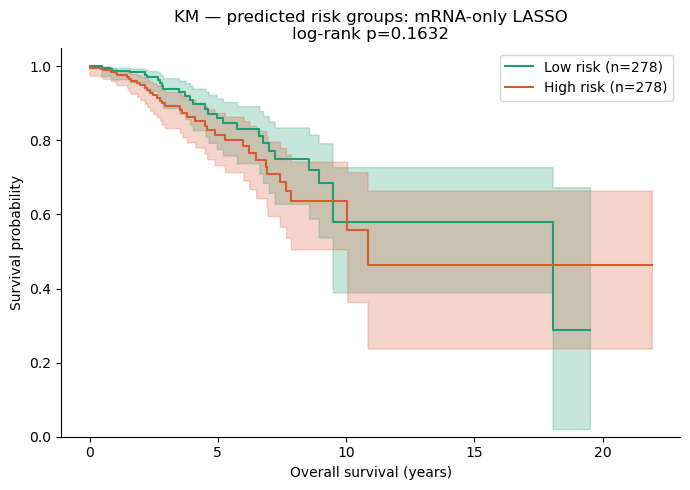

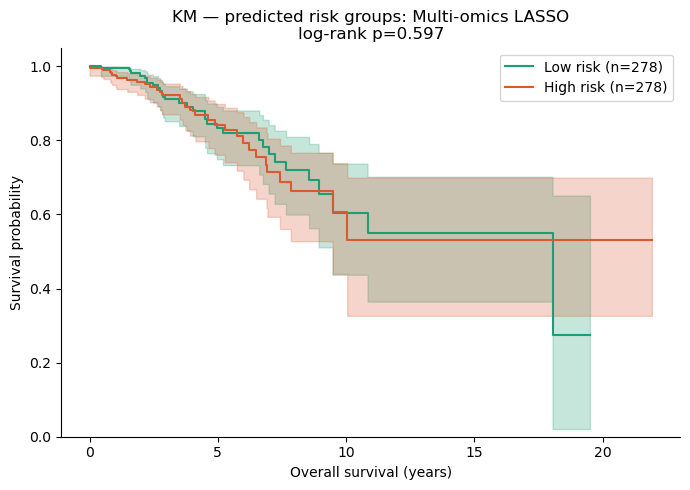

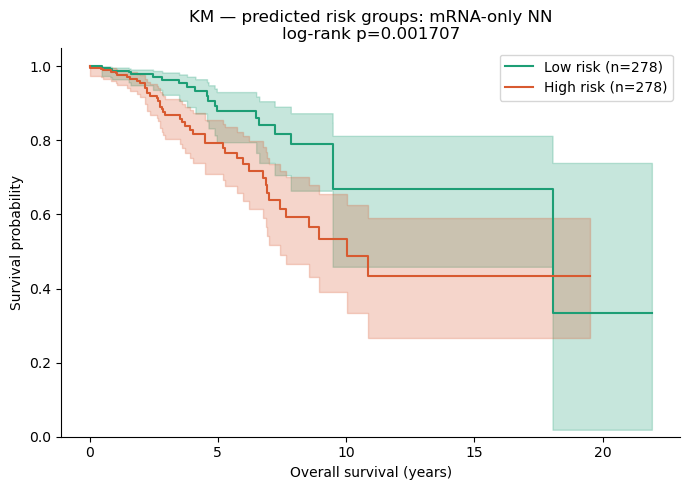

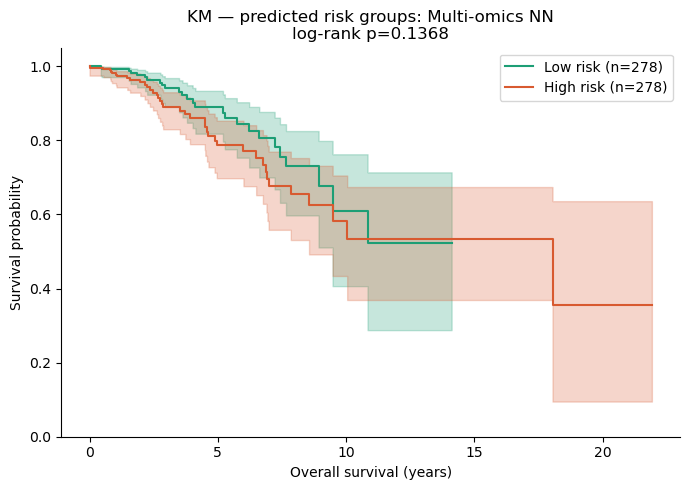

In [9]:

# KM curves from predicted risk scores
km_files = {
    "mRNA-only LASSO":   "../results/tables/lasso_cox_mrna_risk_scores.csv",
    "Multi-omics LASSO": "../results/tables/lasso_cox_multiomics_risk_scores.csv",
    "mRNA-only NN":      "../results/tables/nn_mrna_only_risk_scores.csv",
    "Multi-omics NN":    "../results/tables/nn_integrated_risk_scores.csv",
}

km_results = []
for model_name, fpath in km_files.items():
    if not Path(fpath).exists():
        print(f"Skipping {model_name} — {fpath} not found")
        continue

    scores = pd.read_csv(fpath).set_index("patient")
    common = scores.index.intersection(surv.index)
    d = surv.loc[common].copy()
    d["risk_score"] = scores.loc[common, "risk_score"]
    d["time_years"] = d["time"] / 365.25
    d["risk_group"] = np.where(d["risk_score"] >= d["risk_score"].median(),
                               "High risk", "Low risk")

    lr = logrank_test(
        d.loc[d["risk_group"] == "Low risk",  "time_years"],
        d.loc[d["risk_group"] == "High risk", "time_years"],
        event_observed_A=d.loc[d["risk_group"] == "Low risk",  "event"],
        event_observed_B=d.loc[d["risk_group"] == "High risk", "event"]
    )

    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(7, 5))
    for group, color in [("Low risk", "#1D9E75"), ("High risk", "#D85A30")]:
        sub = d[d["risk_group"] == group]
        kmf.fit(sub["time_years"], sub["event"], label=f"{group} (n={len(sub)})")
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

    ax.set_xlabel("Overall survival (years)")
    ax.set_ylabel("Survival probability")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"KM — predicted risk groups: {model_name}\nlog-rank p={lr.p_value:.4g}")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    fname = model_name.lower().replace(" ", "_").replace("-", "_")
    plt.savefig(f"../results/figures/km_risk_groups_{fname}.png", dpi=300)
    plt.show()

    km_results.append({"model": model_name, "logrank_p": round(lr.p_value, 4),
                       "n_high": (d["risk_group"] == "High risk").sum(),
                       "n_low":  (d["risk_group"] == "Low risk").sum()})

if km_results:
    km_df = pd.DataFrame(km_results)
    km_df.to_csv("../results/tables/km_risk_group_logrank.csv", index=False)

## Kaplan-Meier risk stratification

The KM curves reveal a striking and unexpected result: the **mRNA-only NN** is the only model that achieves statistically significant risk group separation (log-rank p=0.0017). Its predicted risk scores cleanly split patients into two groups with visibly different survival trajectories from the first year onward — the low-risk group reaches approximately 65% survival at 10 years while the high-risk group drops to around 44%. 

The three other models fail to achieve significance: mRNA-only LASSO (p=0.163), Multi-omics LASSO (p=0.597), and Multi-omics NN (p=0.137). The Multi-omics NN in particular shows nearly overlapping curves despite having the highest mean C-index — this disconnect between C-index and KM separation is important and likely reflects the high variance of the Multi-omics NN (fold 1 C-index=0.311), meaning its aggregated risk scores across folds are inconsistent enough to wash out the stratification signal when all patients are pooled together.

The finding that the mRNA-only NN outperforms the multi-omics models on clinical risk stratification does not necessarily mean methylation is uninformative — it may reflect that the current multi-omics NN architecture and training setup (very small network, aggressive regularization, high variance) is not yet optimal for the integrated feature space. This is an important nuance for the discussion section of the report.

## 3) Final Summary Table


In [10]:

# final summary table
km_df = pd.read_csv("../results/tables/km_risk_group_logrank.csv")
report_table = summary.copy()
report_table.columns = ["Model", "Mean C-index", "SD", "Min", "Max"]
report_table = report_table.merge(
    km_df[["model", "logrank_p"]].rename(
        columns={"model": "Model", "logrank_p": "KM log-rank p"}),
    on="Model", how="left"
)
report_table.to_csv("../results/tables/final_model_comparison_table.csv", index=False)
print(report_table.to_string(index=False))

            Model  Mean C-index    SD   Min   Max  KM log-rank p
  mRNA-only LASSO         0.576 0.078 0.495 0.684         0.1632
Multi-omics LASSO         0.585 0.105 0.432 0.701         0.5970
     mRNA-only NN         0.621 0.056 0.563 0.710         0.0017
   Multi-omics NN         0.640 0.195 0.311 0.831         0.1368


### Summary
C-index ranking: Multi-omics NN (0.640) > mRNA-only NN (0.621) > Multi-omics LASSO (0.585) > mRNA-only LASSO (0.576). Adding methylation helps both model types, NNs beat LASSO in both settings, but none of the differences are statistically significant.

KM results: The mRNA-only NN is the only model with significant risk stratification (p=0.0017), not the Multi-omics NN as you might expect. The Multi-omics NN despite having the highest mean C-index shows nearly overlapping KM curves (p=0.137). This is because its extreme fold variance (0.311 to 0.831) makes the aggregated risk scores across folds inconsistent enough to wash out the clinical stratification signal.